c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


贝叶斯优化找到的最佳温度：
Temperature = 92.06 ℃
Observed score = 8.805


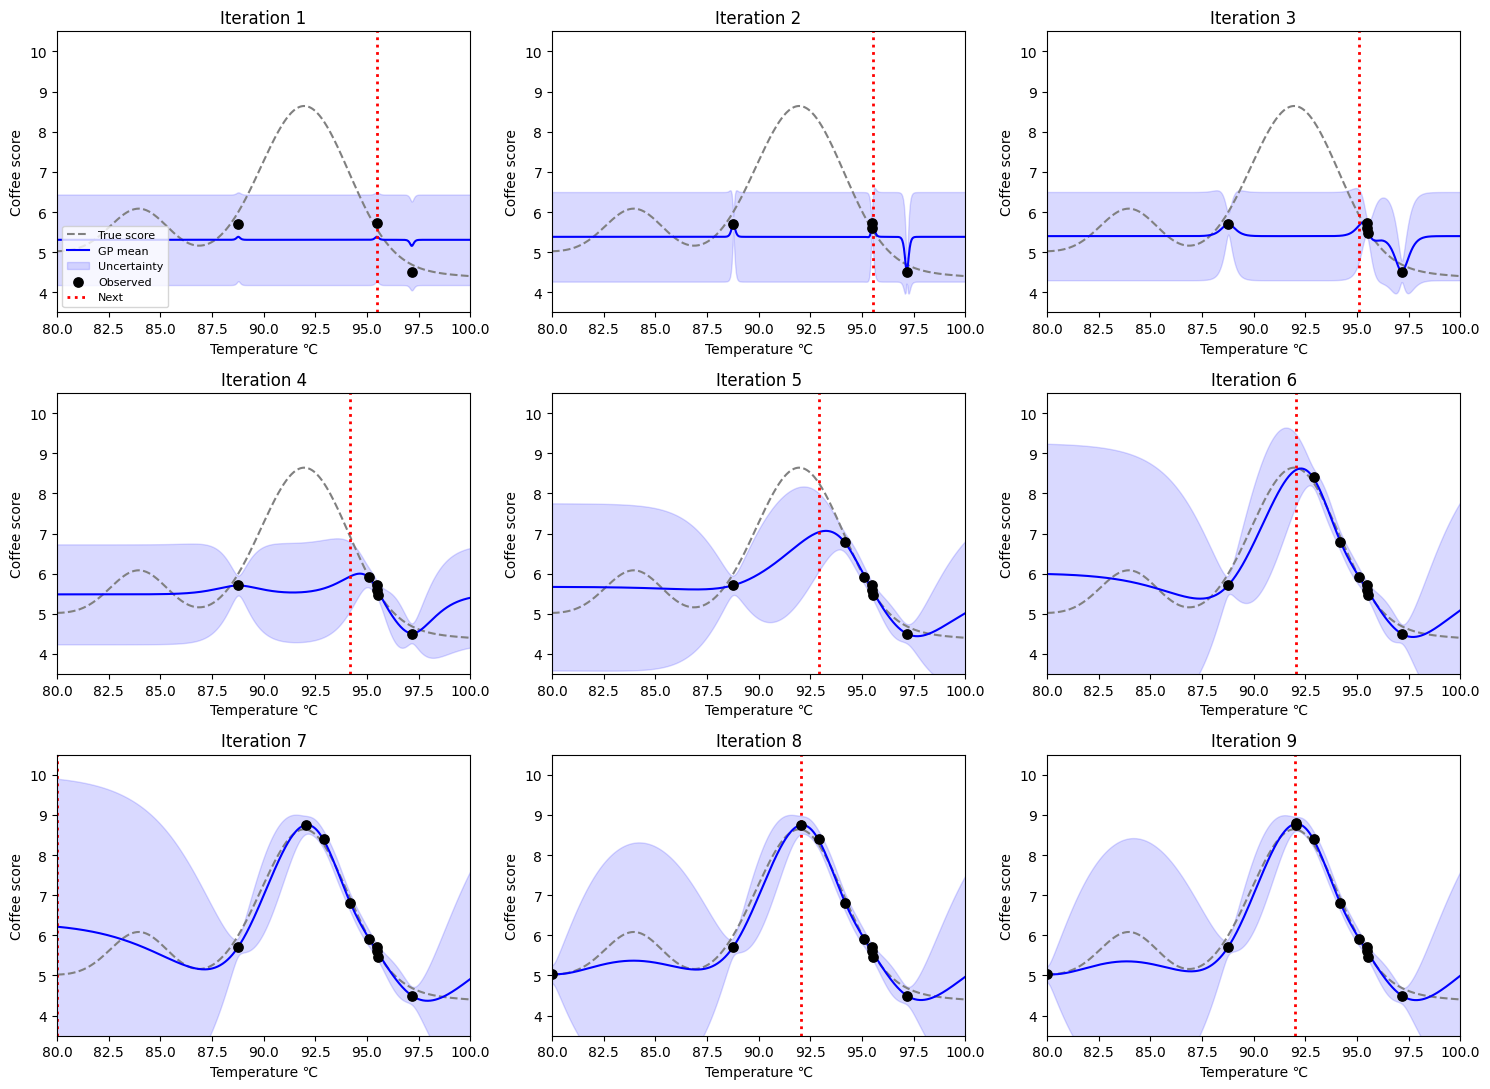

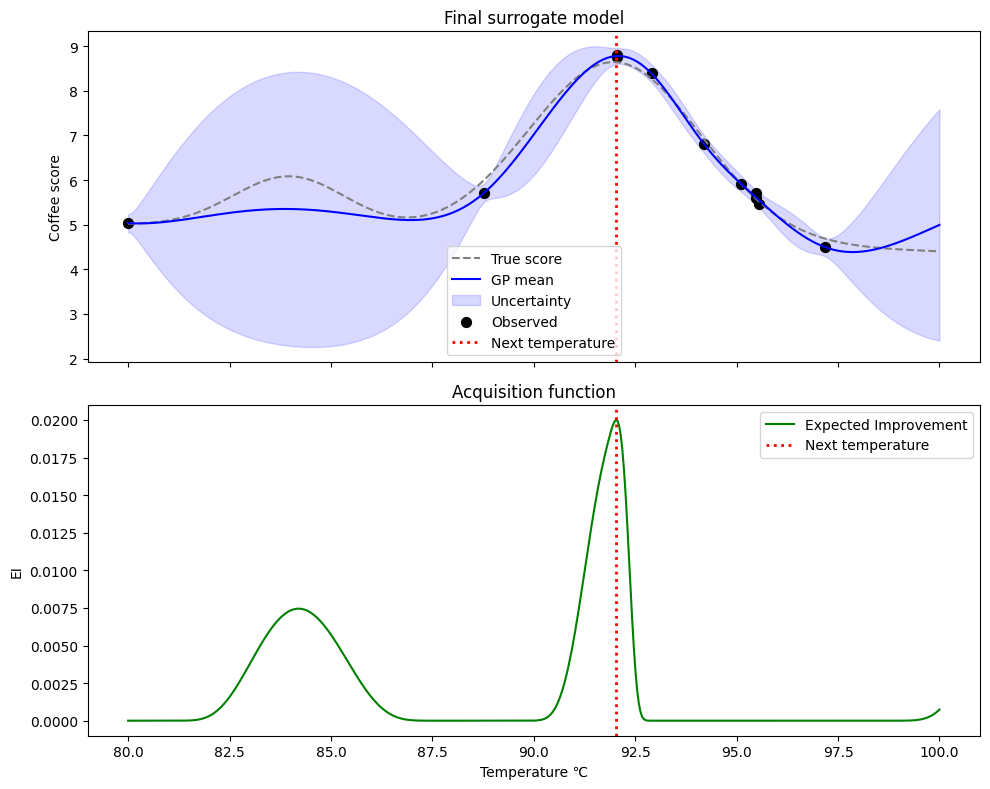

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel

# =========================
# 1. 假设的真实咖啡评分函数
# =========================
# 注意：真实场景中这个函数是未知的，这里只是为了模拟实验和可视化
def true_score(x):
    """
    x: 冲煮温度，单位 ℃
    返回：咖啡评分
    """
    x = np.asarray(x)

    # 假设 92℃ 附近最好，84℃ 附近也有一个小高峰
    score = (
        5
        + 4.0 * np.exp(-((x - 92) / 3.0) ** 2)
        + 1.2 * np.exp(-((x - 84) / 2.0) ** 2)
        - 0.03 * (x - 80)
    )
    return score


# =========================
# 2. 模拟一次真实实验
# =========================
def experiment(x, rng):
    """
    模拟真实试喝评分。
    真实实验中可能有噪声，比如评委状态不同、咖啡豆批次差异等。
    """
    noise = rng.normal(0, 0.15)
    return true_score(x) + noise


# =========================
# 3. 期望提升 EI 采集函数
# =========================
def expected_improvement(X_grid, model, y_best, xi=0.01):
    """
    Expected Improvement，期望提升。
    
    X_grid: 候选温度点
    model: 高斯过程代理模型
    y_best: 当前已经观察到的最高评分
    xi: 探索参数，越大越鼓励探索
    """
    mu, std = model.predict(X_grid, return_std=True)

    std = std.reshape(-1)
    mu = mu.reshape(-1)

    # 防止除以 0
    std = np.maximum(std, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / std

    ei = improvement * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std == 0.0] = 0.0

    return ei


# =========================
# 4. 贝叶斯优化主流程
# =========================
rng = np.random.default_rng(42)

# 温度范围：80℃ 到 100℃
lower_bound = 80
upper_bound = 100

# 用于画图和搜索下一个点的密集网格
X_grid = np.linspace(lower_bound, upper_bound, 500).reshape(-1, 1)

# 初始随机试 3 个温度
X_observed = rng.uniform(lower_bound, upper_bound, size=(3, 1))
y_observed = np.array([experiment(x[0], rng) for x in X_observed])

# 高斯过程模型
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * Matern(length_scale=3.0, length_scale_bounds=(0.1, 20), nu=2.5)
    + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-5, 1))
)

model = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    random_state=42,
    n_restarts_optimizer=5
)

# 记录每一步，用于可视化
history = []

# 进行 9 轮贝叶斯优化
n_iterations = 9

for i in range(n_iterations):
    # 训练代理模型
    model.fit(X_observed, y_observed)

    # 预测每个温度的评分均值和不确定性
    mu, std = model.predict(X_grid, return_std=True)

    # 当前最好的已知评分
    y_best = np.max(y_observed)

    # 计算 EI
    ei = expected_improvement(X_grid, model, y_best)

    # 选择 EI 最大的位置作为下一次实验温度
    next_index = np.argmax(ei)
    next_x = X_grid[next_index]

    # 保存当前状态，用于后面画图
    history.append({
        "iteration": i + 1,
        "X_observed": X_observed.copy(),
        "y_observed": y_observed.copy(),
        "mu": mu.copy(),
        "std": std.copy(),
        "ei": ei.copy(),
        "next_x": next_x.copy()
    })

    # 做下一次真实实验
    next_y = experiment(next_x[0], rng)

    # 加入观测数据
    X_observed = np.vstack([X_observed, next_x.reshape(1, 1)])
    y_observed = np.append(y_observed, next_y)


# =========================
# 5. 输出最终结果
# =========================
best_index = np.argmax(y_observed)
best_temperature = X_observed[best_index][0]
best_score = y_observed[best_index]

print("贝叶斯优化找到的最佳温度：")
print(f"Temperature = {best_temperature:.2f} ℃")
print(f"Observed score = {best_score:.3f}")


# =========================
# 6. 可视化：每轮贝叶斯优化过程
# =========================
true_y_grid = true_score(X_grid.ravel())

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()

for ax, item in zip(axes, history):
    iteration = item["iteration"]
    X_obs = item["X_observed"]
    y_obs = item["y_observed"]
    mu = item["mu"]
    std = item["std"]
    next_x = item["next_x"]

    # 真实函数，仅用于演示。现实中我们看不到这条曲线。
    ax.plot(
        X_grid.ravel(),
        true_y_grid,
        linestyle="--",
        color="gray",
        label="True score"
    )

    # GP 预测均值
    ax.plot(
        X_grid.ravel(),
        mu,
        color="blue",
        label="GP mean"
    )

    # 置信区间
    ax.fill_between(
        X_grid.ravel(),
        mu - 1.96 * std,
        mu + 1.96 * std,
        color="blue",
        alpha=0.15,
        label="Uncertainty"
    )

    # 已经实验过的点
    ax.scatter(
        X_obs.ravel(),
        y_obs,
        color="black",
        s=45,
        zorder=3,
        label="Observed"
    )

    # 下一次准备实验的点
    ax.axvline(
        next_x[0],
        color="red",
        linestyle=":",
        linewidth=2,
        label="Next"
    )

    ax.set_title(f"Iteration {iteration}")
    ax.set_xlim(lower_bound, upper_bound)
    ax.set_ylim(3.5, 10.5)
    ax.set_xlabel("Temperature ℃")
    ax.set_ylabel("Coffee score")

# 只在第一个子图显示图例，避免太乱
axes[0].legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()


# =========================
# 7. 可视化：最后一轮的 EI 采集函数
# =========================
last = history[-1]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 上图：代理模型
axes[0].plot(
    X_grid.ravel(),
    true_y_grid,
    linestyle="--",
    color="gray",
    label="True score"
)
axes[0].plot(
    X_grid.ravel(),
    last["mu"],
    color="blue",
    label="GP mean"
)
axes[0].fill_between(
    X_grid.ravel(),
    last["mu"] - 1.96 * last["std"],
    last["mu"] + 1.96 * last["std"],
    color="blue",
    alpha=0.15,
    label="Uncertainty"
)
axes[0].scatter(
    last["X_observed"].ravel(),
    last["y_observed"],
    color="black",
    s=50,
    label="Observed"
)
axes[0].axvline(
    last["next_x"][0],
    color="red",
    linestyle=":",
    linewidth=2,
    label="Next temperature"
)
axes[0].set_ylabel("Coffee score")
axes[0].set_title("Final surrogate model")
axes[0].legend()

# 下图：EI 采集函数
axes[1].plot(
    X_grid.ravel(),
    last["ei"],
    color="green",
    label="Expected Improvement"
)
axes[1].axvline(
    last["next_x"][0],
    color="red",
    linestyle=":",
    linewidth=2,
    label="Next temperature"
)
axes[1].set_xlabel("Temperature ℃")
axes[1].set_ylabel("EI")
axes[1].set_title("Acquisition function")
axes[1].legend()

plt.tight_layout()
plt.show()


In [5]:
def plot_target_function(target_function, x_range=(-5, 5), num_points=1000, seed=42):
    """
    绘制目标函数的图像曲线
    
    参数:
        target_function: 目标函数 (接受torch.Tensor输入，返回torch.Tensor输出)
        x_range: x的范围元组 (min, max)
        num_points: 用于绘制曲线的点数
        seed: 随机种子，用于保证噪声的一致性
    """
    # 设置随机种子以获得一致的结果
    torch.manual_seed(seed)
    
    # 生成x值
    x_min, x_max = x_range
    x_tensor = torch.linspace(x_min, x_max, num_points).unsqueeze(-1)  # 形状 [num_points, 1]
    
    # 计算y值
    with torch.no_grad():  # 禁用梯度计算
        y_tensor = target_function(x_tensor)
    
    # 转换为numpy数组用于绘图
    x_numpy = x_tensor.squeeze().numpy()
    y_numpy = y_tensor.squeeze().numpy()
    
    # 绘制图像
    plt.figure(figsize=(10, 6))
    plt.plot(x_numpy, y_numpy, 'b-', linewidth=1, label='f(x) = sin(x) + 0.1*x + noise')
    
    # 绘制无噪声的真实函数作为对比
    true_y = np.sin(x_numpy) + 0.1 * x_numpy
    plt.plot(x_numpy, true_y, 'r--', linewidth=1, alpha=0.8, label='True function: sin(x) + 0.1*x')
    
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Target Function Visualization')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

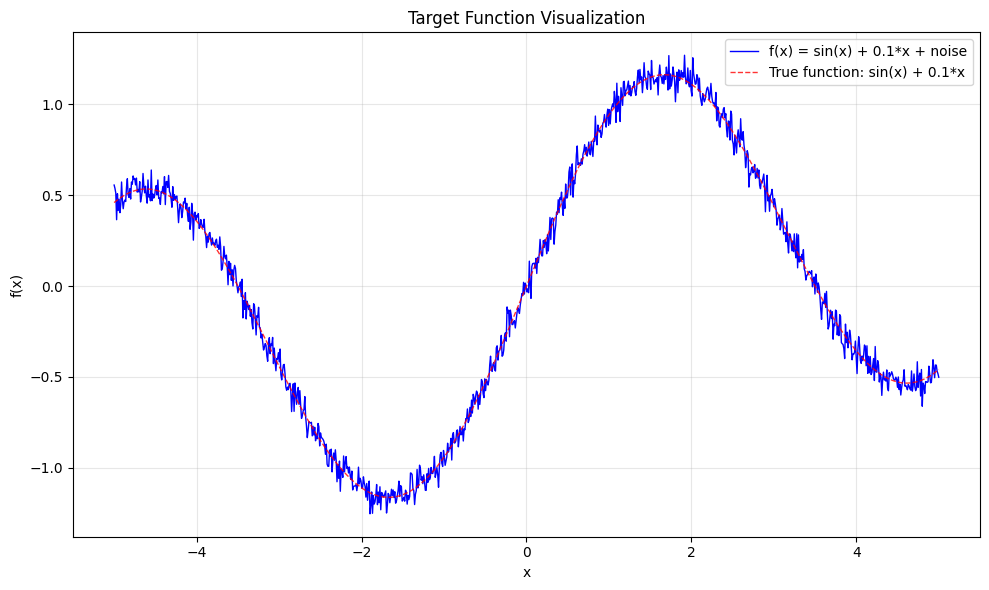

In [6]:
plot_target_function(target_function, x_range=(-5, 5))

Iteration 1/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


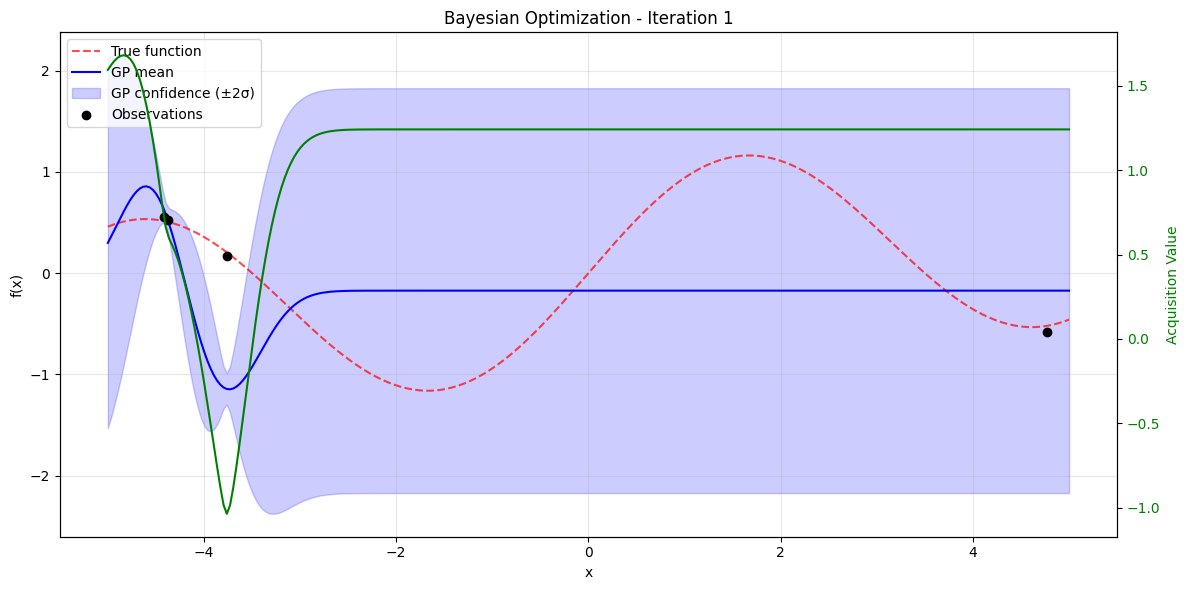

Iteration 2/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


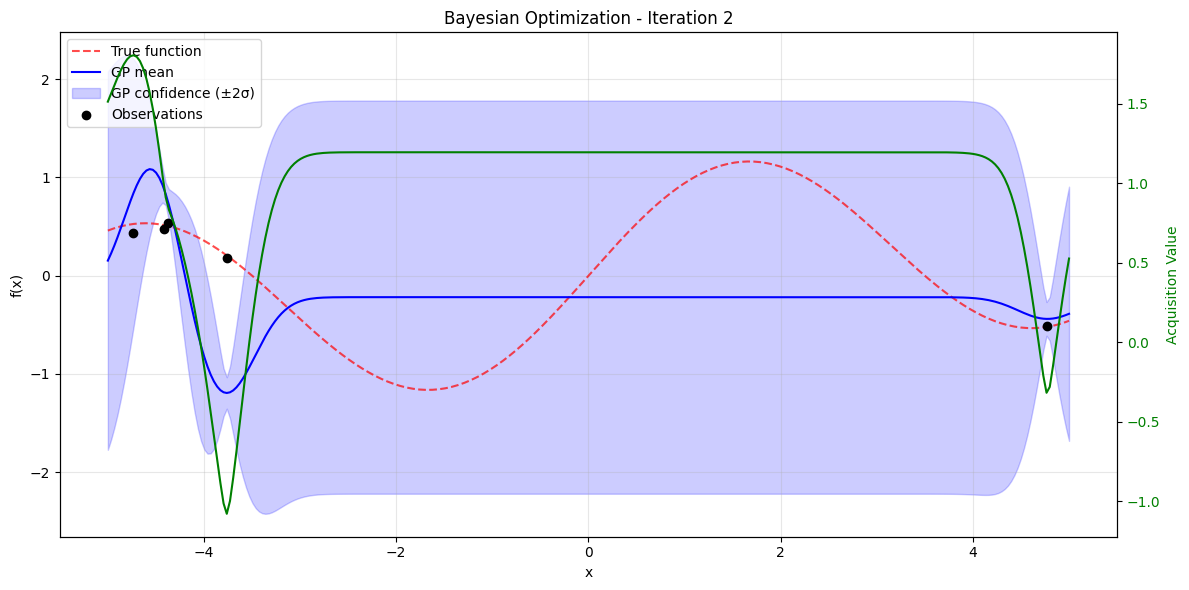

Iteration 3/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


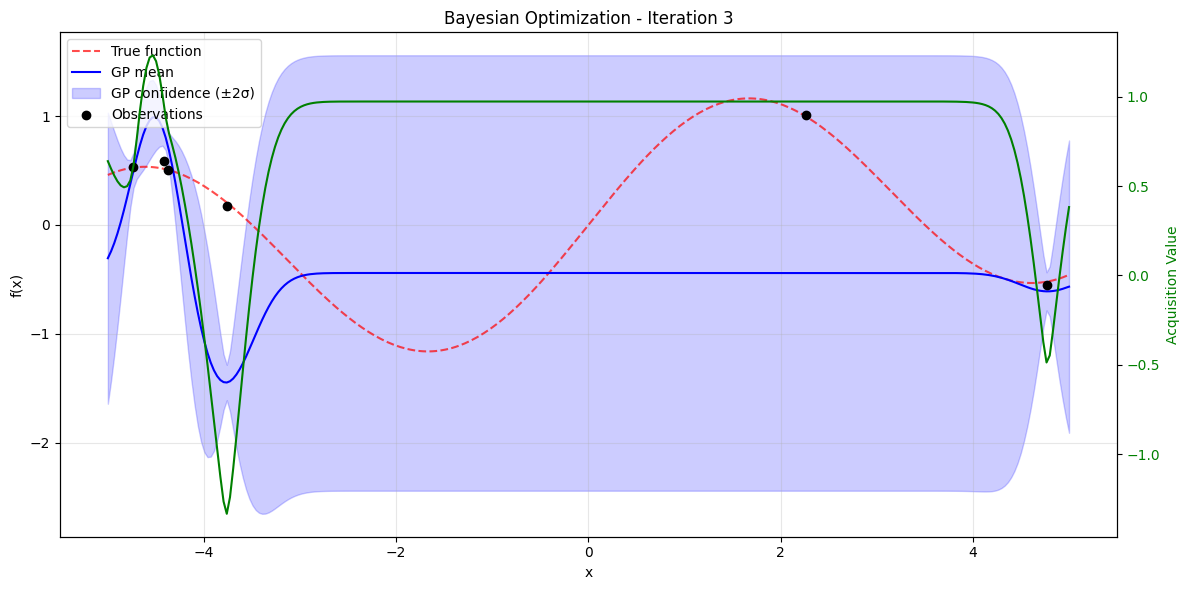

Iteration 4/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


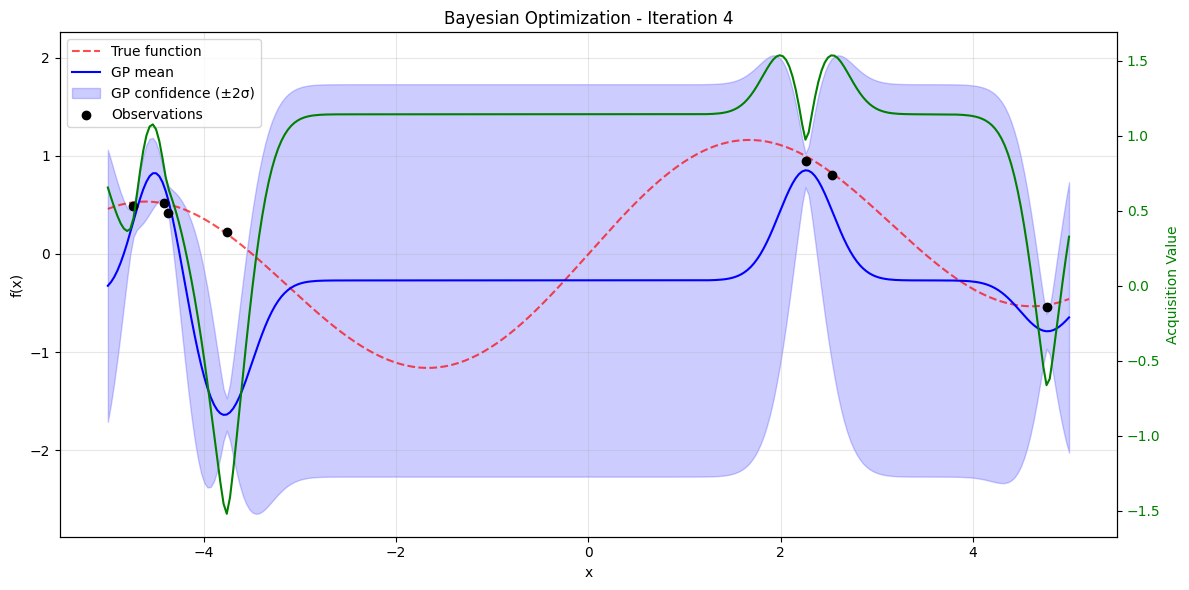

Iteration 5/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


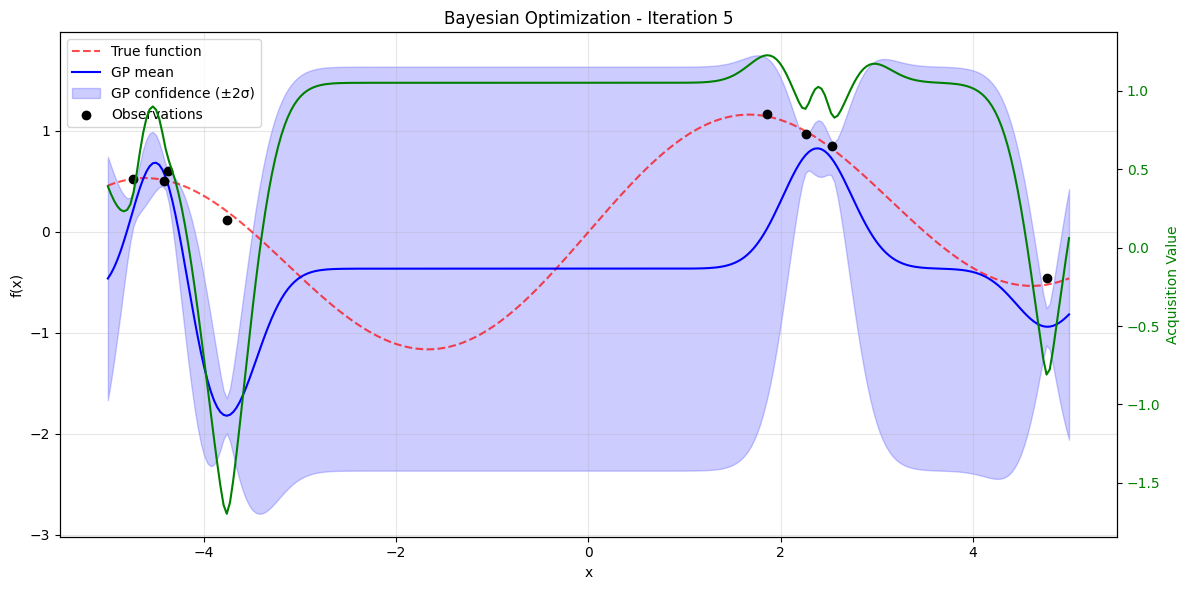

Iteration 6/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


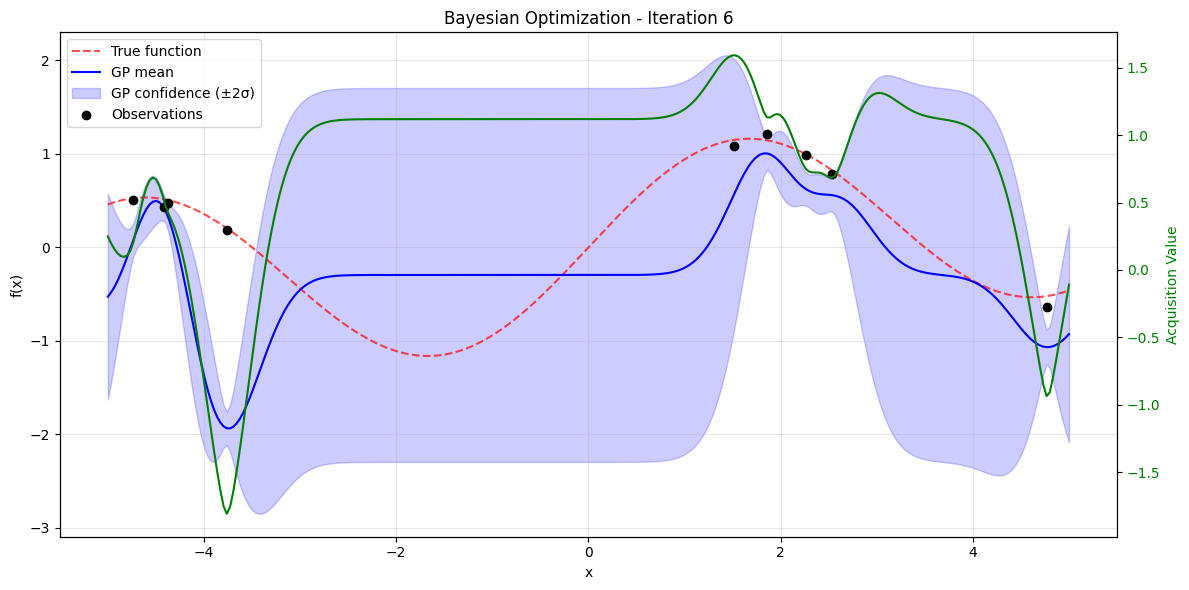

Iteration 7/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


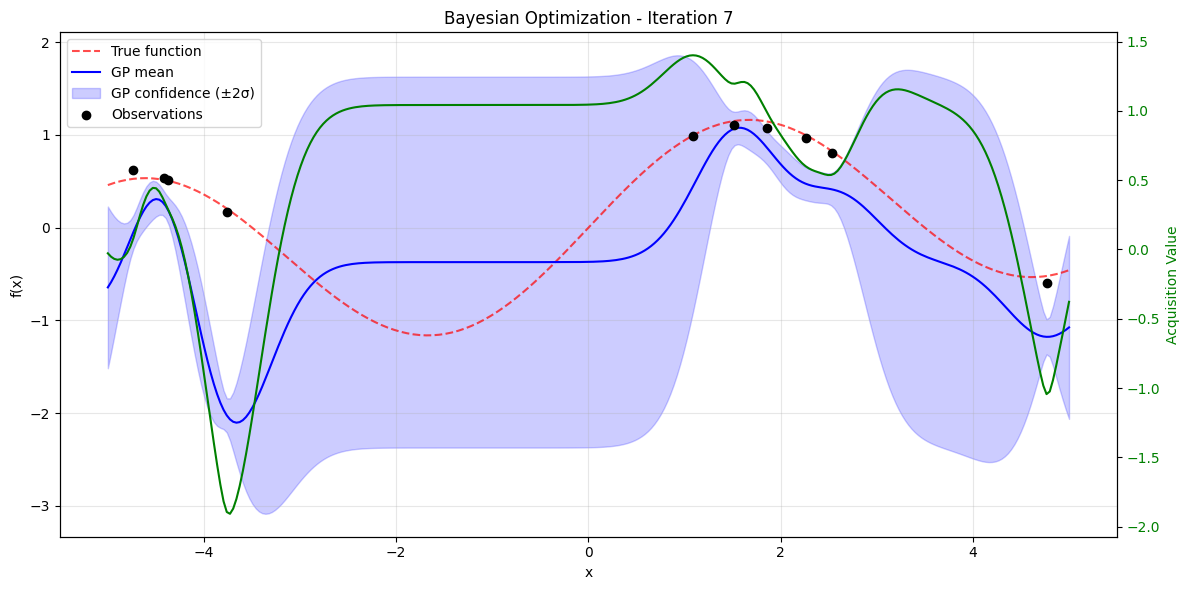

Iteration 8/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


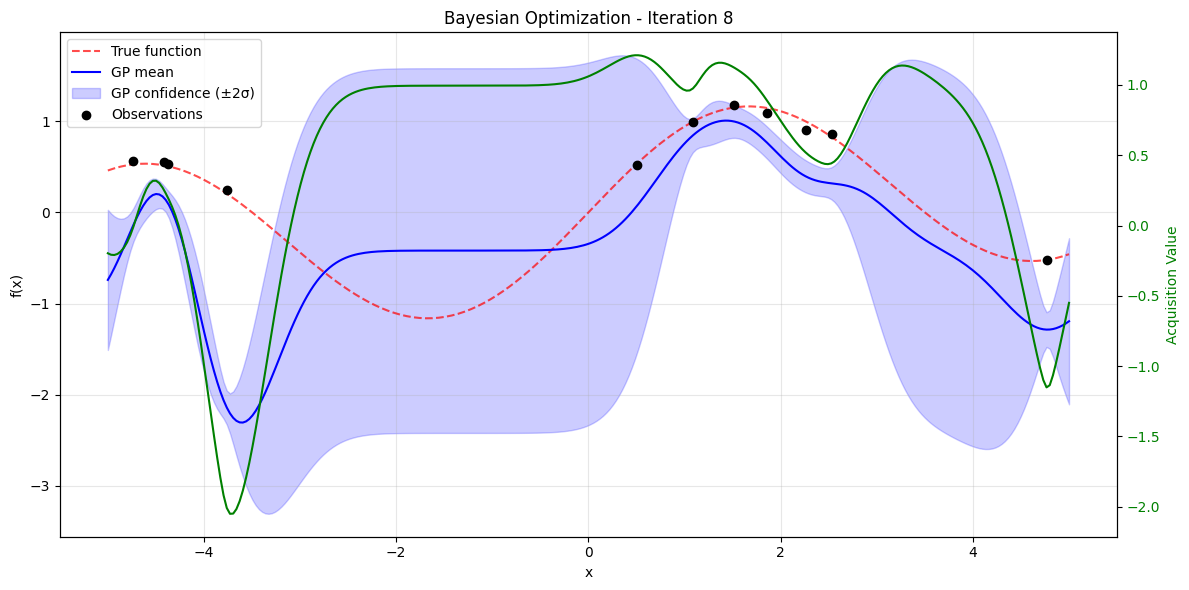

Iteration 9/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


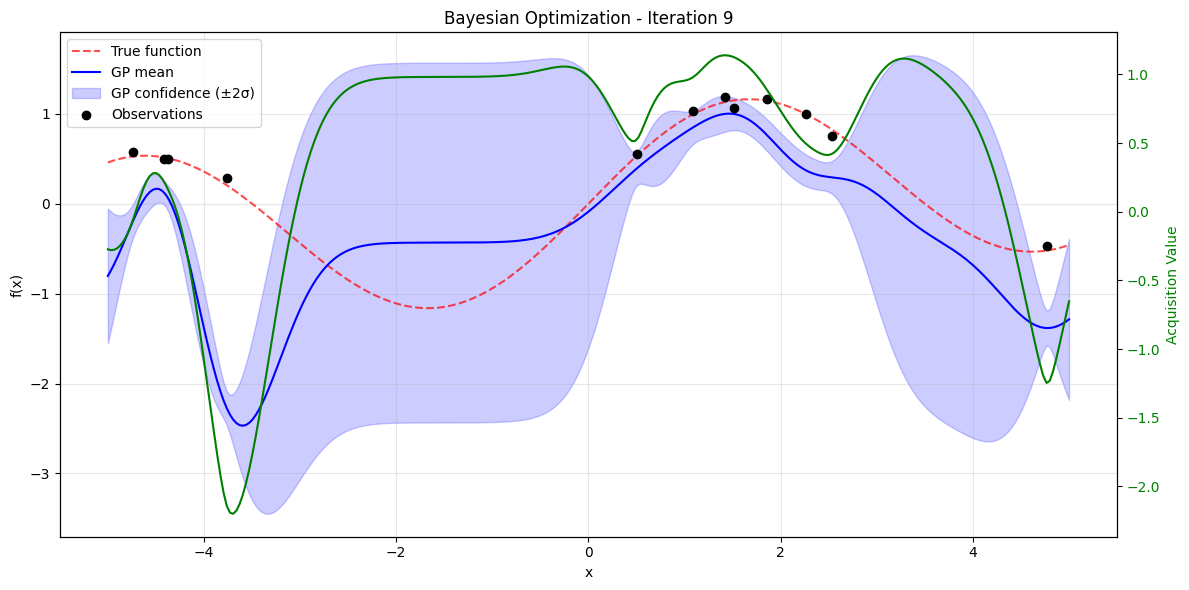

Iteration 10/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


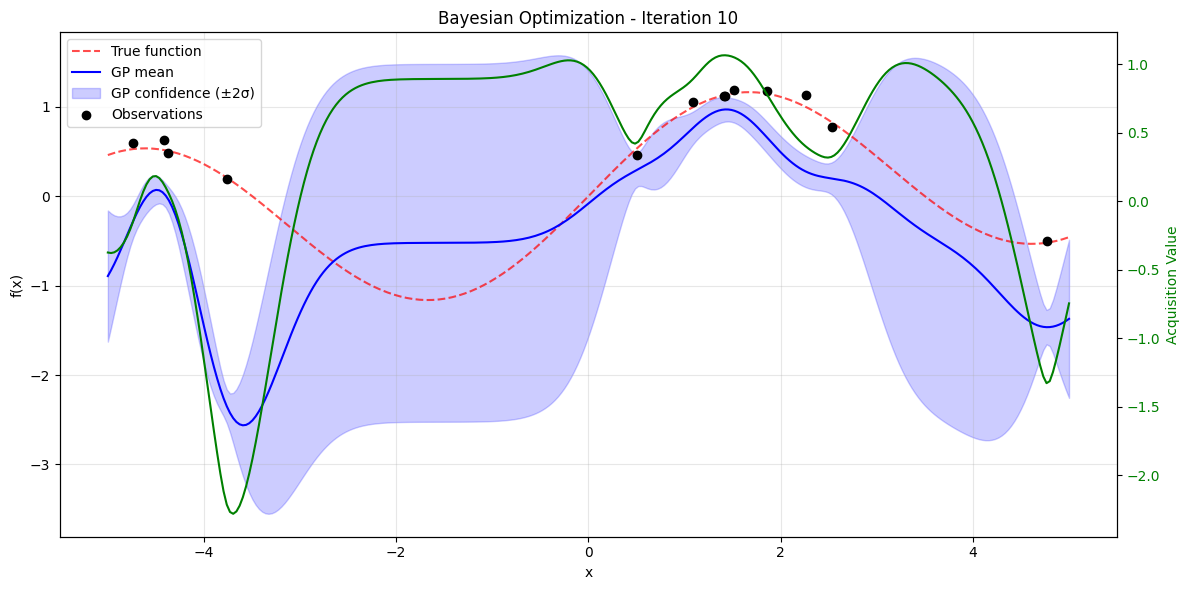

Iteration 11/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


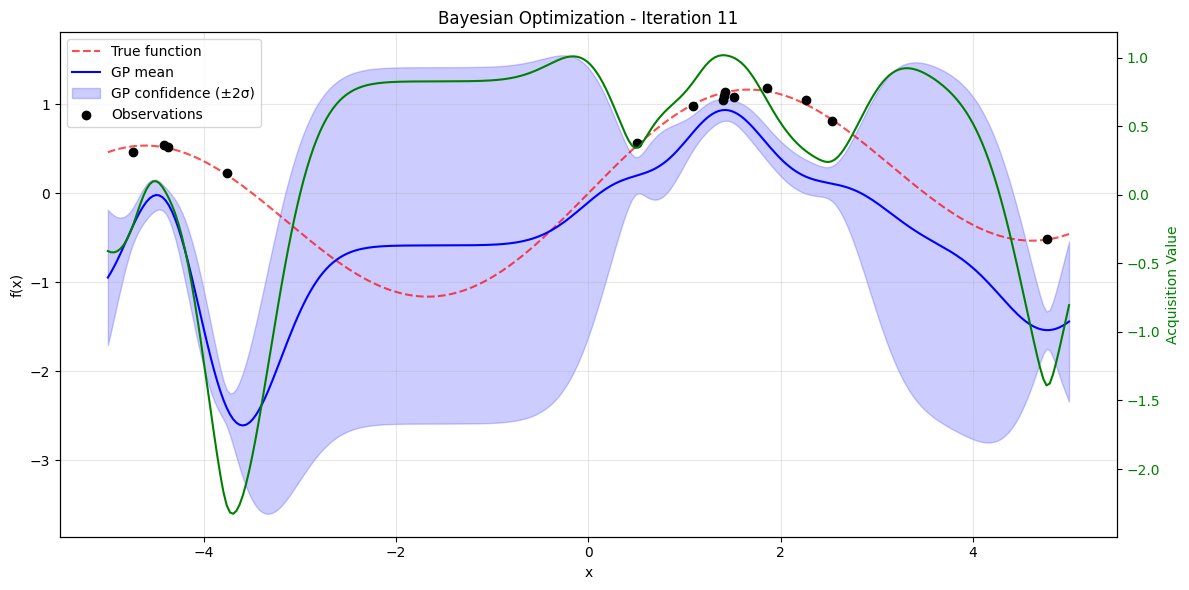

Iteration 12/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


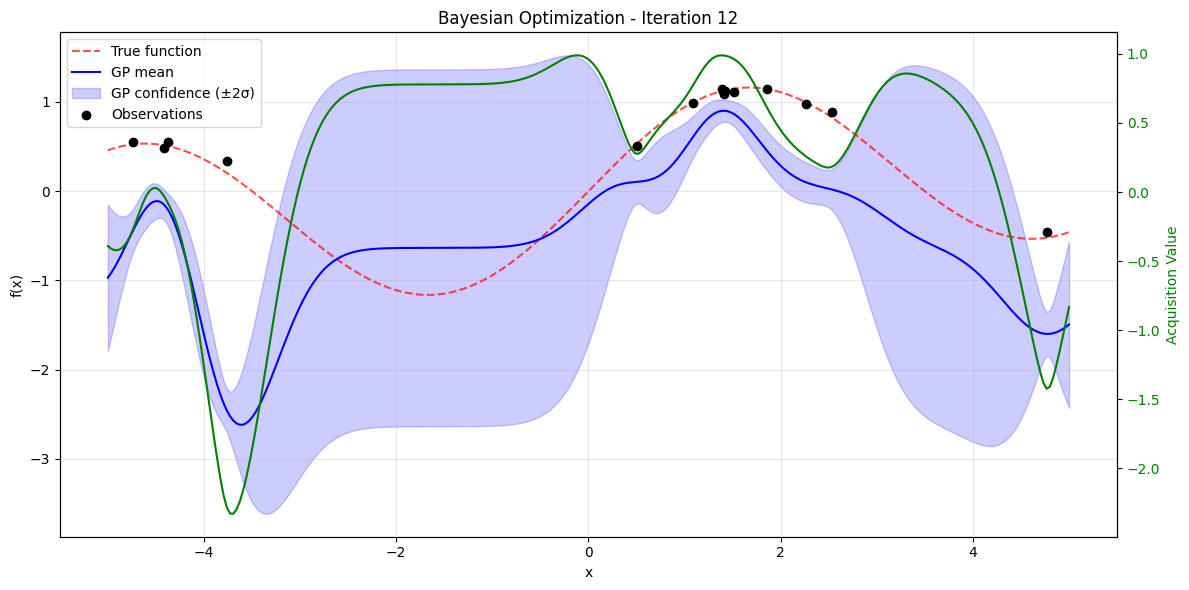

Iteration 13/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


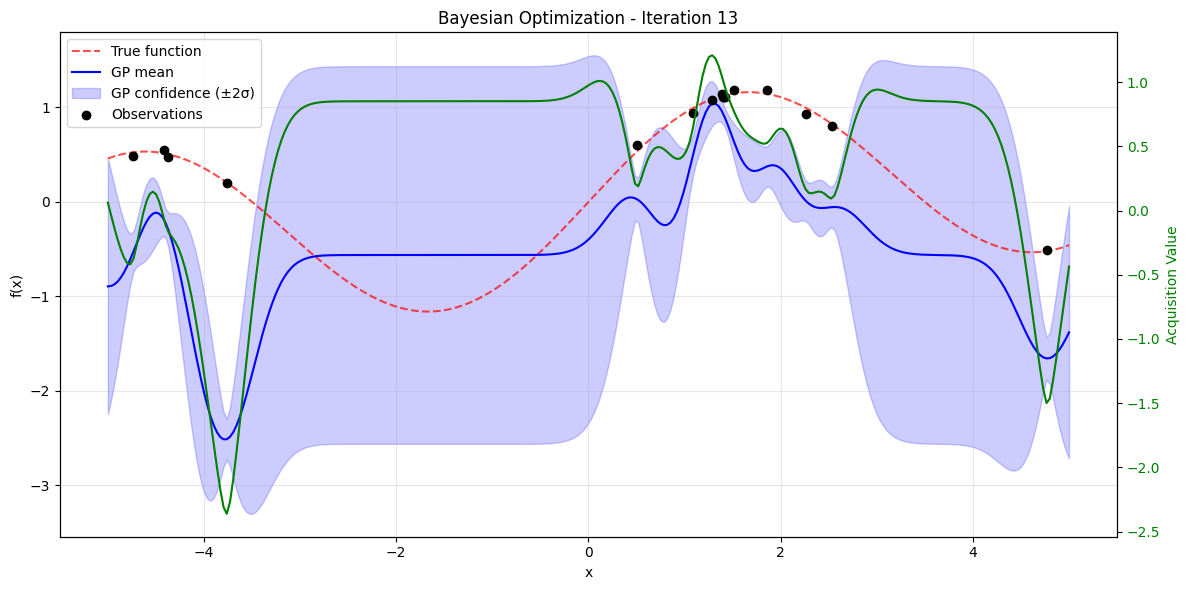

Iteration 14/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


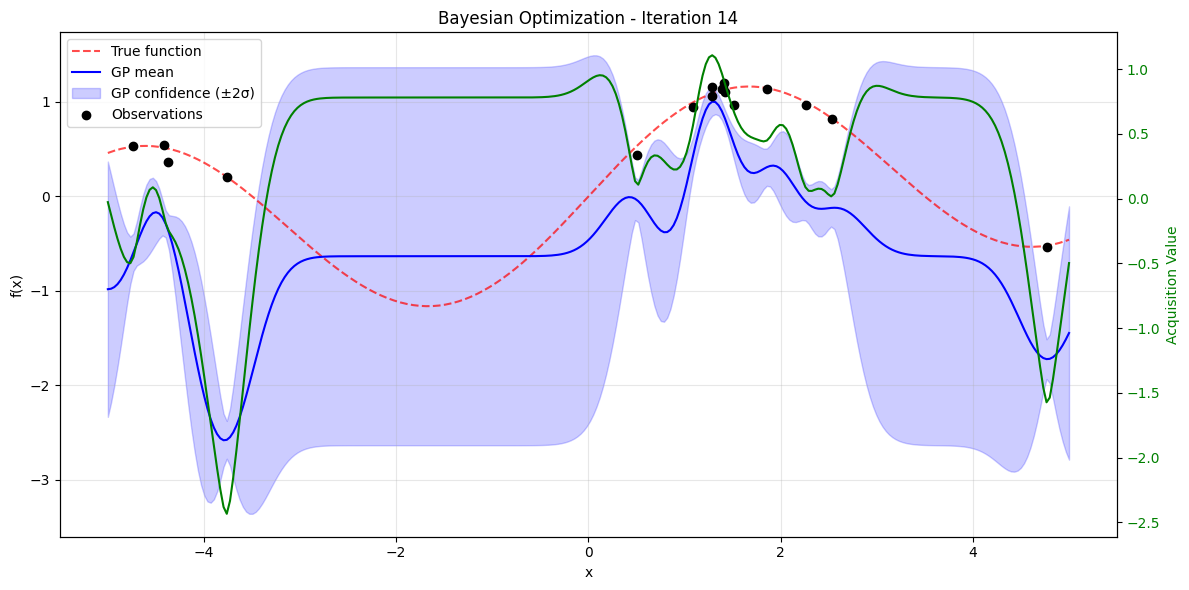

Iteration 15/15


c:\Users\yuhaoran\Desktop\repo\venv\Lib\site-packages\botorch\models\utils\assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(


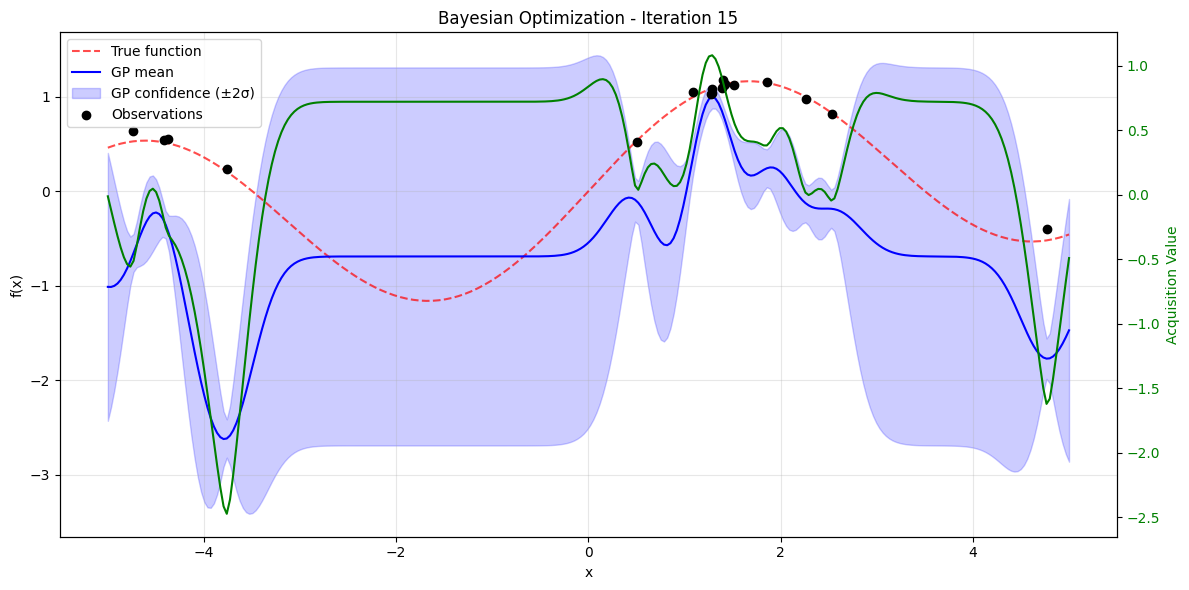


Optimization completed!
Best point: x=1.2856, f(x)=1.0684


In [3]:
figures = bayesian_optimization_with_plots()